# Assignment 4: Customer Churn Prediction using Multi-Layer Perceptron (MLP)

## Overview
**Churn** occurs when a customer stops doing business with an entity (e.g., canceling a Netflix subscription or switching mobile carriers).

**Goal:** Use a Multi-Layer Perceptron (MLP) to analyze historical patterns (tenure, contract type, monthly charges) and predict the probability of a customer leaving.
- **1** → Churn (customer left)
- **0** → Retain (customer stayed)

**Dataset:** IBM Telco Customer Churn dataset

---
## Step 1: Data Exploration
Load the dataset, inspect its structure, check for missing values, and convert data types as needed.

> **Note:** The `TotalCharges` column is stored as a string in the raw CSV and must be converted to a float.

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_score,
                             recall_score, f1_score, roc_auc_score)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version     : {np.__version__}')
print(f'Pandas version    : {pd.__version__}')

I0000 00:00:1773654920.097373   12900 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773654920.097868   12900 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773654920.146853   12900 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773654921.498728   12900 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773654921.499055   12900 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
NumPy version     : 2.4.2
Pandas version    : 3.0.0


In [2]:
# --- Load Dataset ---
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# --- Basic Info ---
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str   

In [4]:
# --- Statistical Summary ---
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
# --- Check Missing Values ---
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No NaN values detected (initial pass)')

# TotalCharges is stored as a string; spaces represent customers with 0 tenure
print(f'\nTotalCharges dtype: {df["TotalCharges"].dtype}')
print(f'Sample TotalCharges values with spaces: {df[df["TotalCharges"].str.strip() == ""]["TotalCharges"].count()} rows')

Missing values per column:
No NaN values detected (initial pass)

TotalCharges dtype: str
Sample TotalCharges values with spaces: 11 rows


In [6]:
# --- Convert TotalCharges from string to float ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges became NaN (customers with 0 tenure)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape after cleaning: {df.shape}')
print(f'TotalCharges dtype after conversion: {df["TotalCharges"].dtype}')

Dataset shape after cleaning: (7032, 21)
TotalCharges dtype after conversion: float64


Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.58%


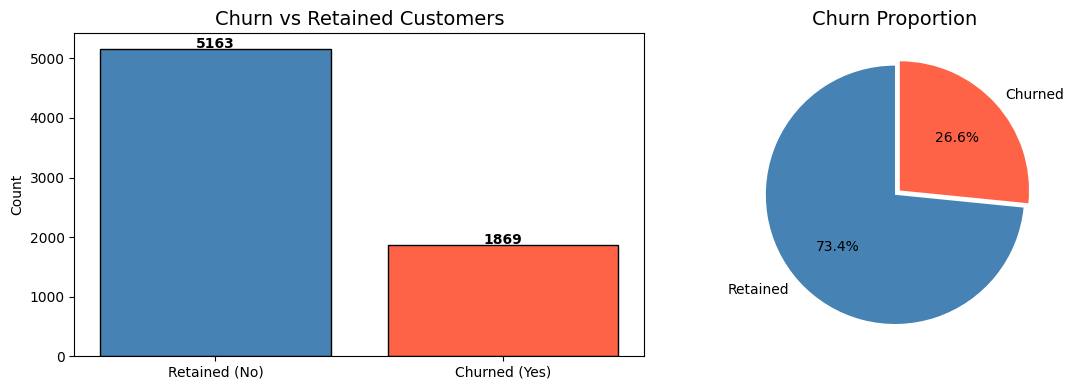

In [7]:
# --- Churn Distribution ---
churn_counts = df['Churn'].value_counts()
print('Churn Distribution:')
print(churn_counts)
print(f'\nChurn Rate: {churn_counts["Yes"] / len(df) * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Retained (No)', 'Churned (Yes)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn vs Retained Customers', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Proportion', fontsize=14)

plt.tight_layout()
plt.show()

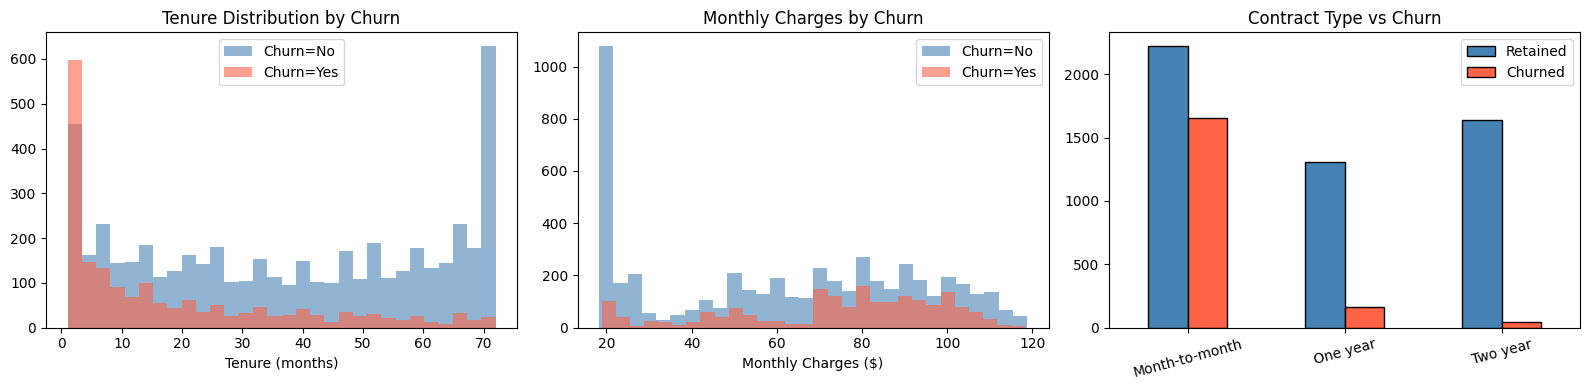

In [8]:
# --- EDA: Key Features vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tenure distribution
for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    axes[0].hist(df[df['Churn'] == label]['tenure'], bins=30,
                 alpha=0.6, color=color, label=f'Churn={label}')
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# Monthly Charges
for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
    axes[1].hist(df[df['Churn'] == label]['MonthlyCharges'], bins=30,
                 alpha=0.6, color=color, label=f'Churn={label}')
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

# Contract type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[2], color=['steelblue', 'tomato'],
                    edgecolor='black')
axes[2].set_title('Contract Type vs Churn')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

---
## Step 2: Feature Engineering
Transform categorical variables into numerical format so the MLP can process them.

### Strategy:
| Column | Type | Treatment |
|--------|------|-----------|
| `gender` | Binary | Map to `Is_Male` (1=Male, 0=Female) |
| `SeniorCitizen` | Already 0/1 | Keep as-is |
| `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn` | Binary Yes/No | Map to 1/0 |
| `MultipleLines`, `InternetService`, `OnlineSecurity`, etc. | Multi-class | One-Hot Encoding |
| `Contract`, `PaymentMethod` | Multi-class | One-Hot Encoding |
| `tenure`, `MonthlyCharges`, `TotalCharges` | Numeric | StandardScaler |

In [9]:
# --- Drop customerID (not useful for prediction) ---
df.drop('customerID', axis=1, inplace=True)

# --- Binary mappings ---
# Gender → Is_Male (1=Male, 0=Female)
df['Is_Male'] = df['gender'].map({'Male': 1, 'Female': 0})
df.drop('gender', axis=1, inplace=True)

# Yes/No columns → 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Target variable: Churn → 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Binary columns encoded.')
print(df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'Is_Male']].head())

Binary columns encoded.
   Partner  Dependents  PhoneService  PaperlessBilling  Churn  Is_Male
0        1           0             0                 1      0        0
1        0           0             1                 0      0        1
2        0           0             1                 1      1        1
3        0           0             0                 0      0        1
4        0           0             1                 1      1        0


In [10]:
# --- One-Hot Encoding for multi-class categorical columns ---
categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'Shape after One-Hot Encoding: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape after One-Hot Encoding: (7032, 31)
Columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Is_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


---
## Step 3: Building the MLP Architecture

### Data Preparation
- **Split** data into features (X) and target (y)
- **Train/Test split**: 80% training, 20% testing
- **Standardize** numeric features using `StandardScaler`

### MLP Architecture
```
Input Layer  →  [Input features]
    ↓
Dense(64, ReLU)  →  BatchNormalization  →  Dropout(0.3)
    ↓
Dense(32, ReLU)  →  BatchNormalization  →  Dropout(0.3)
    ↓
Dense(16, ReLU)
    ↓
Output: Dense(1, Sigmoid)  →  Probability of Churn
```
- **ReLU** (Rectified Linear Unit): prevents vanishing gradients in hidden layers
- **Sigmoid** output: squashes output to [0,1] for binary probability
- **Dropout**: regularization to prevent overfitting
- **BatchNormalization**: stabilizes and speeds up training

In [11]:
# --- Prepare Features and Target ---
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'Class balance : {y.value_counts().to_dict()}')

Features shape: (7032, 30)
Target shape  : (7032,)
Class balance : {0: 5163, 1: 1869}


In [12]:
# --- Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')
print(f'Train churn % : {y_train.mean()*100:.2f}%')
print(f'Test churn %  : {y_test.mean()*100:.2f}%')

Training set  : 5625 samples
Test set      : 1407 samples
Train churn % : 26.58%
Test churn %  : 26.58%


In [13]:
# --- Feature Scaling with StandardScaler ---
# Fit only on training data to prevent data leakage!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'Train mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train std  (should be ~1): {X_train_scaled.std():.4f}')

Scaling complete.
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000


In [14]:
# --- Build the MLP Model ---
tf.random.set_seed(42)

input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    # --- Hidden Layer 1 ---
    layers.Dense(64, activation='relu', input_shape=(input_dim,),
                 name='hidden_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    # --- Hidden Layer 2 ---
    layers.Dense(32, activation='relu', name='hidden_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.3, name='dropout_2'),

    # --- Hidden Layer 3 ---
    layers.Dense(16, activation='relu', name='hidden_3'),

    # --- Output Layer ---
    layers.Dense(1, activation='sigmoid', name='output')
], name='Churn_MLP')

model.summary()

E0000 00:00:1773654923.250642   12900 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773654923.250922   12942 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773654923.261672   12900 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "Churn_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

---
## Step 4: Compilation & Training

| Parameter | Value | Reason |
|-----------|-------|--------|
| **Loss** | `binary_crossentropy` | Standard for binary (0/1) classification |
| **Optimizer** | `Adam` | Adaptive learning rate – faster convergence |
| **Metrics** | `accuracy`, `AUC` | Accuracy + Area Under ROC Curve |
| **Epochs** | 50 | Number of full passes through training data |
| **Batch size** | 32 | Samples per gradient update |
| **Early Stopping** | patience=10 | Stops if val_loss doesn't improve |

In [15]:
# --- Compile the Model ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# --- Callbacks ---
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print('Model compiled successfully.')

Model compiled successfully.


In [16]:
# --- Compute Class Weights (handle class imbalance) ---
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_arr))
print(f'Class weights: {class_weight_dict}')

# --- Train the Model ---
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,       # 15% of training data for validation
    class_weight=class_weight_dict,  # Penalise churn errors more
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {np.int64(0): np.float64(0.6809927360774818), np.int64(1): np.float64(1.8812709030100334)}


Epoch 1/50


  1/150 ━━━━━━━━━━━━━━━━━━━━ 4:18 2s/step - accuracy: 0.5625 - auc: 0.6148 - loss: 0.5734

 26/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5719 - auc: 0.6087 - loss: 0.7015 

 53/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5913 - auc: 0.6379 - loss: 0.6951

...

136/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7634 - auc: 0.8635 - loss: 0.4517


Epoch 41: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7680 - auc: 0.8639 - loss: 0.4544 - val_accuracy: 0.7630 - val_auc: 0.8483 - val_loss: 0.4942 - learning_rate: 1.2500e-04


Epoch 41: early stopping


Restoring model weights from the end of the best epoch: 31.


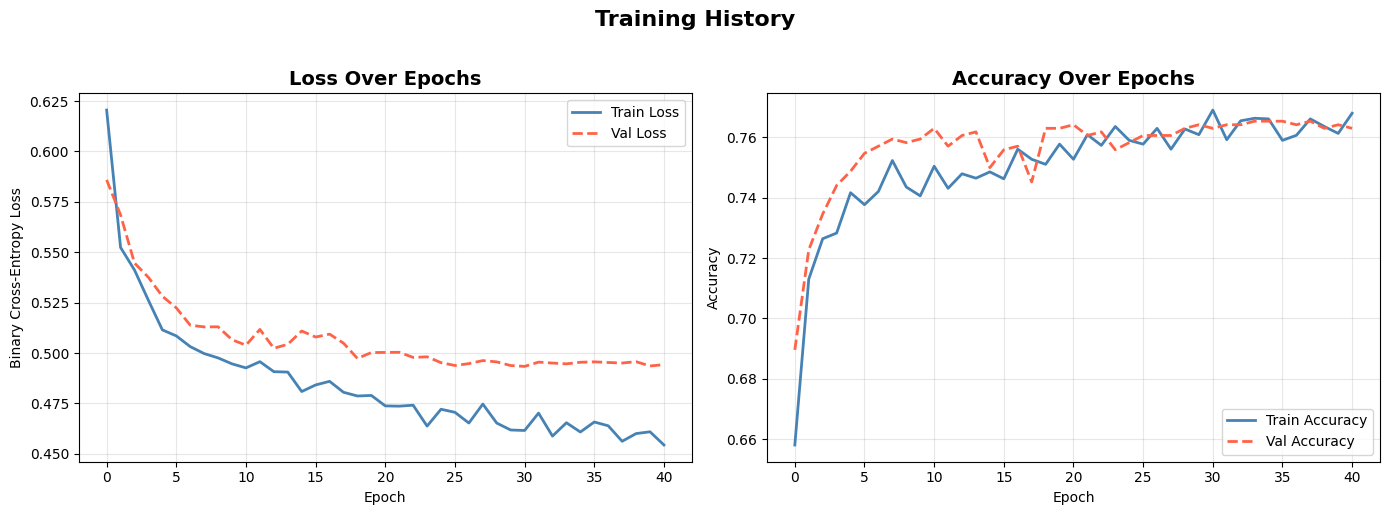

In [17]:
# --- Plot Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato',
             linewidth=2, linestyle='--')
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy',
             color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',
             color='tomato', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5: Evaluation Metrics

### Why Not Just Accuracy?
Since churners are typically a **minority** (~26% of customers), a model that always predicts "No Churn" would achieve ~74% accuracy — but would catch **zero** churners!

We use more informative metrics:

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Precision** | TP / (TP + FP) | Of all predicted churners, how many actually left? |
| **Recall** | TP / (TP + FN) | Of all actual churners, how many did the model catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |
| **AUC-ROC** | Area under ROC curve | Overall discriminative ability (0.5=random, 1.0=perfect) |
| **Confusion Matrix** | 2×2 table | TP, TN, FP, FN breakdown |

In [18]:
# --- Generate Predictions ---
y_pred_prob = model.predict(X_test_scaled).flatten()   # Probabilities

# Threshold tuning: lower threshold catches more churners (higher recall)
# Default is 0.5; try 0.4 to improve recall on minority class
THRESHOLD = 0.4
y_pred = (y_pred_prob >= THRESHOLD).astype(int)

print(f'Decision Threshold : {THRESHOLD}')
print(f'Total test samples : {len(y_test)}')
print(f'Predicted churners : {y_pred.sum()}')
print(f'Actual churners    : {y_test.sum()}')

 1/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Decision Threshold : 0.4
Total test samples : 1407
Predicted churners : 725
Actual churners    : 374


In [19]:
# --- Classification Report ---
print('='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred,
                             target_names=['Retained (0)', 'Churned (1)']))

# Individual metrics
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_prob)

print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'AUC-ROC   : {auc:.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Retained (0)       0.92      0.61      0.73      1033
 Churned (1)       0.44      0.85      0.58       374

    accuracy                           0.67      1407
   macro avg       0.68      0.73      0.65      1407
weighted avg       0.79      0.67      0.69      1407

Precision : 0.4372
Recall    : 0.8476
F1-Score  : 0.5769
AUC-ROC   : 0.8238


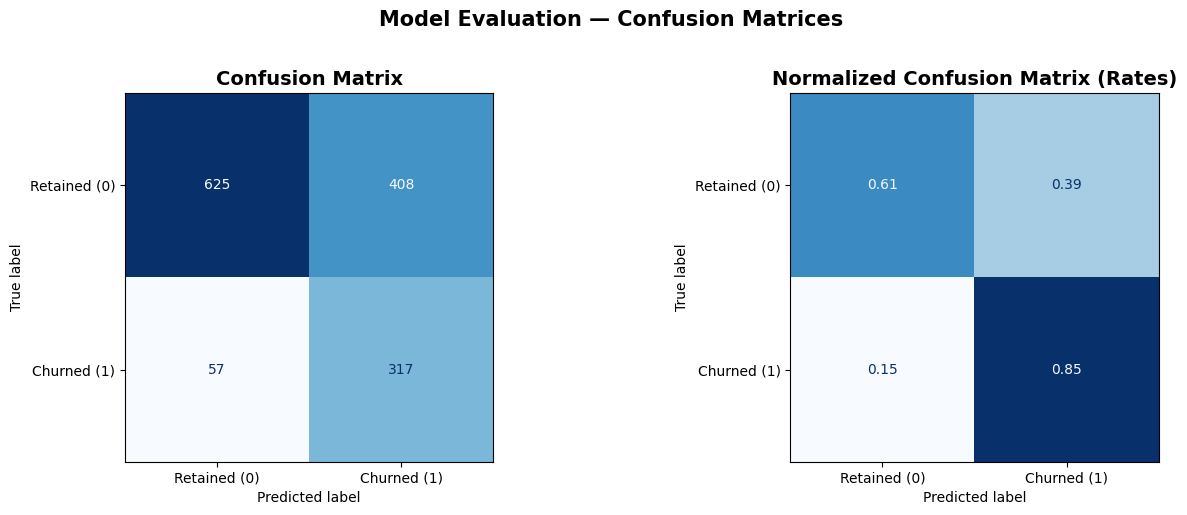


True Negatives  (TN): 625  — Correctly predicted Retained
False Positives (FP): 408  — Predicted Churn, actually Retained
False Negatives (FN): 57  — Predicted Retained, actually Churned
True Positives  (TP): 317  — Correctly predicted Churned


In [20]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labeled confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Retained (0)', 'Churned (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Normalized confusion matrix (rates)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=['Retained (0)', 'Churned (1)'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Normalized Confusion Matrix (Rates)', fontsize=14, fontweight='bold')

plt.suptitle('Model Evaluation — Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Negatives  (TN): {tn}  — Correctly predicted Retained')
print(f'False Positives (FP): {fp}  — Predicted Churn, actually Retained')
print(f'False Negatives (FN): {fn}  — Predicted Retained, actually Churned')
print(f'True Positives  (TP): {tp}  — Correctly predicted Churned')

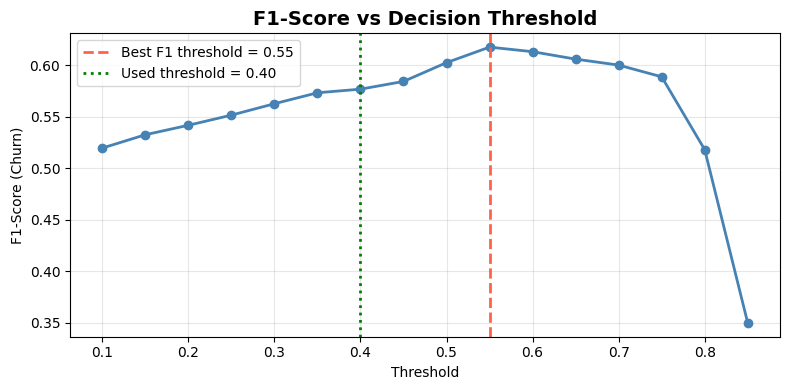

Best threshold for F1: 0.55  →  F1 = 0.6177


In [21]:
# --- Threshold Sweep: Find best threshold for F1 ---
thresholds = np.arange(0.1, 0.9, 0.05)
f1_sweep   = [f1_score(y_test, (y_pred_prob >= t).astype(int)) for t in thresholds]
best_t     = thresholds[np.argmax(f1_sweep)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_sweep, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_t, color='tomato', linestyle='--', linewidth=2,
            label=f'Best F1 threshold = {best_t:.2f}')
plt.axvline(0.40, color='green', linestyle=':', linewidth=2,
            label='Used threshold = 0.40')
plt.title('F1-Score vs Decision Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('F1-Score (Churn)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best threshold for F1: {best_t:.2f}  →  F1 = {max(f1_sweep):.4f}')

---
## Step 6: Model Summary Table

A comprehensive summary of the trained MLP model architecture and performance metrics.

In [22]:
# --- Model Architecture Summary ---
print('='*70)
print('MODEL ARCHITECTURE SUMMARY')
print('='*70)
model.summary()

# Count parameters
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\nTotal Parameters   : {total_params:,}')
print(f'Trainable Parameters: {trainable_params:,}')

MODEL ARCHITECTURE SUMMARY


Model: "Churn_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,597 (57.02 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 9,604 (37.52 KB)


Total Parameters   : 4,993
Trainable Parameters: 4,801


In [23]:
# --- Layer-by-Layer Summary Table ---
print('='*70)
print('LAYER-BY-LAYER DETAILS')
print('='*70)
print(f'{"Layer Name":<25} {"Type":<25} {"# Parameters":>15}')
print('-'*65)
for layer in model.layers:
    num_params = layer.count_params()
    print(f'{layer.name:<25} {type(layer).__name__:<25} {num_params:>15,}')
print('-'*65)
print(f'{"TOTAL":<50} {model.count_params():>15,}')

LAYER-BY-LAYER DETAILS
Layer Name                Type                         # Parameters
-----------------------------------------------------------------
hidden_1                  Dense                               1,984
bn_1                      BatchNormalization                    256
dropout_1                 Dropout                                 0
hidden_2                  Dense                               2,080
bn_2                      BatchNormalization                    128
dropout_2                 Dropout                                 0
hidden_3                  Dense                                 528
output                    Dense                                  17
-----------------------------------------------------------------
TOTAL                                                        4,993


In [24]:
# --- Performance Summary Table ---
from tensorflow.keras import backend as K

# Evaluate on test set
test_loss, test_accuracy, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)

metrics_data = {
    'Metric'     : ['Test Loss', 'Test Accuracy', 'Test AUC-ROC',
                    'Precision', 'Recall', 'F1-Score'],
    'Value'      : [f'{test_loss:.4f}', f'{test_accuracy*100:.2f}%',
                    f'{test_auc:.4f}', f'{precision:.4f}',
                    f'{recall:.4f}', f'{f1:.4f}'],
    'Interpretation': [
        'Binary cross-entropy on unseen data',
        'Overall correct predictions',
        'Discriminative ability (1.0 = perfect)',
        'Of predicted churners, fraction correct',
        'Of actual churners, fraction detected',
        'Harmonic mean of Precision & Recall'
    ]
}

summary_df = pd.DataFrame(metrics_data)
print('='*70)
print('FINAL PERFORMANCE METRICS SUMMARY')
print('='*70)
print(summary_df.to_string(index=False))
print('\nsummary_df shown below as a styled table:')
summary_df

FINAL PERFORMANCE METRICS SUMMARY
       Metric  Value                          Interpretation
    Test Loss 0.5265     Binary cross-entropy on unseen data
Test Accuracy 72.35%             Overall correct predictions
 Test AUC-ROC 0.8239  Discriminative ability (1.0 = perfect)
    Precision 0.4372 Of predicted churners, fraction correct
       Recall 0.8476   Of actual churners, fraction detected
     F1-Score 0.5769     Harmonic mean of Precision & Recall

summary_df shown below as a styled table:


,Metric,Value,Interpretation
0,Test Loss,0.5265,Binary cross-entropy on unseen data
1,Test Accuracy,72.35%,Overall correct predictions
2,Test AUC-ROC,0.8239,Discriminative ability (1.0 = perfect)
3,Precision,0.4372,"Of predicted churners, fraction correct"
4,Recall,0.8476,"Of actual churners, fraction detected"
5,F1-Score,0.5769,Harmonic mean of Precision & Recall


In [25]:
# --- Training Configuration Summary ---
config_data = {
    'Parameter'         : ['Optimizer', 'Learning Rate', 'Loss Function',
                           'Epochs (max)', 'Batch Size', 'Validation Split',
                           'Early Stopping Patience', 'Dropout Rate',
                           'Hidden Layers', 'Activation (hidden)',
                           'Activation (output)'],
    'Value'             : ['Adam', '0.001', 'Binary Cross-Entropy',
                           '50', '32', '15%',
                           '10', '0.3',
                           '3 (64→32→16)', 'ReLU',
                           'Sigmoid'],
    'Reason'            : [
        'Adaptive learning rate, widely used',
        'Default Adam LR, good starting point',
        'Standard for binary classification',
        'Early stopping prevents overtraining',
        'Balances speed and stability',
        'Monitor generalization during training',
        'Stop if no improvement for 10 epochs',
        'Regularization to prevent overfitting',
        'Progressively narrows representation',
        'Prevents vanishing gradient',
        'Outputs probability in [0, 1]'
    ]
}

config_df = pd.DataFrame(config_data)
print('='*70)
print('TRAINING CONFIGURATION')
print('='*70)
print(config_df.to_string(index=False))
config_df

TRAINING CONFIGURATION
              Parameter                Value                                 Reason
              Optimizer                 Adam    Adaptive learning rate, widely used
          Learning Rate                0.001   Default Adam LR, good starting point
          Loss Function Binary Cross-Entropy     Standard for binary classification
           Epochs (max)                   50   Early stopping prevents overtraining
             Batch Size                   32           Balances speed and stability
       Validation Split                  15% Monitor generalization during training
Early Stopping Patience                   10   Stop if no improvement for 10 epochs
           Dropout Rate                  0.3  Regularization to prevent overfitting
          Hidden Layers         3 (64→32→16)   Progressively narrows representation
    Activation (hidden)                 ReLU            Prevents vanishing gradient
    Activation (output)              Sigmoid         

,Parameter,Value,Reason
0,Optimizer,Adam,"Adaptive learning rate, widely used"
1,Learning Rate,0.001,"Default Adam LR, good starting point"
2,Loss Function,Binary Cross-Entropy,Standard for binary classification
3,Epochs (max),50,Early stopping prevents overtraining
4,Batch Size,32,Balances speed and stability
5,Validation Split,15%,Monitor generalization during training
6,Early Stopping Patience,10,Stop if no improvement for 10 epochs
7,Dropout Rate,0.3,Regularization to prevent overfitting
8,Hidden Layers,3 (64→32→16),Progressively narrows representation
9,Activation (hidden),ReLU,Prevents vanishing gradient


---
## Conclusion

### What We Built
A **Multi-Layer Perceptron (MLP)** neural network to predict customer churn using the Telco Customer Churn dataset.

### Key Takeaways

1. **Data Preprocessing is Critical**: The `TotalCharges` column was stored as a string — we converted it to float and dropped rows with missing values.

2. **Feature Engineering Matters**: We used binary mapping for Yes/No columns (e.g., `Churn → 1/0`) and One-Hot Encoding for multi-class features (e.g., `Contract`, `InternetService`).

3. **Accuracy Alone is Misleading**: With class imbalance (~26% churn), a naive classifier would get ~74% accuracy but catch 0 churners. **Precision, Recall, and AUC** are better metrics.

4. **Regularization Helps**: Dropout and BatchNormalization prevent overfitting and stabilize training.

5. **Early Stopping is Smart**: It monitors validation loss and stops training when improvement plateaus, saving compute and preventing overfitting.

### Business Interpretation
- High **Recall** → model catches more actual churners (important for proactive retention offers)
- High **Precision** → fewer wasted retention campaigns sent to loyal customers
- The ideal balance depends on business cost: *cost of missing a churner* vs. *cost of unnecessary retention spend*